In [1]:
import numpy as np
# import imageio
import scipy
# import itertools
import matplotlib.pyplot as plt
from tqdm import tqdm
# import scipy.fftpack
# import csv 
import os
import cv2
import tifffile
from PIL import Image
import h5py
# import array 
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit
from skimage.feature import peak_local_max

import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.FRC_lib as frc
import brighteyes_ism.analysis.Deconv_lib as dec
import brighteyes_ism.analysis.FocusISM_lib as fism
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.analysis.Tools_lib as tool
import brighteyes_ism.dataio.mcs as mcs
import brighteyes_ism.analysis.Deconv_lib as dec
import brighteyes_ism.simulation.PSF_sim as sim

# from nanopyx import eSRRF
# from nanopyx import SRRF
# from nanopyx.core.transform.sr_temporal_correlations import calculate_eSRRF_temporal_correlations

from scipy.ndimage import fourier_shift, shift 
from os import path
from IPython.display import display, HTML

In [5]:
dir = os.getcwd()

file = 'Qdots_37mW_FOV5um_64x64_100rip_5msPixel'

# Qdots_37mW_FOV5um_64x64_100rip_5msPixel # fototubo?
# Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8
# Qdots_770nm_34mW_FOV3um_32x32_50rip_5msPixel_ROI7
# Qdots_770nm_34mW_FOV5um_64x64_30rip_5msPixel_ROI5
# Qdots_770nm_34mW_FOV5um_64x64_50rip_5msPixel_ROI4
# Qdots_770nm_34mW_FOV5um_64x64_60rip_5msPixel_ROI6

filename = path.join(dir,'images','2025 07 07-08 Qdots',file) # input
savename = path.join(dir,'images','output',file) # output
savenameSOFI = path.join(dir,'images','output','SOFI',file)
# filename = '/Users/margauxbouzin/Library/CloudStorage/GoogleDrive-margaux.bouzin@unimib.it/Drive condivisi/BioPhotonics/Margaux/ISS ISM/2025 07 07-08 Qdots/Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2'
# savename = '/Users/margauxbouzin/Library/CloudStorage/GoogleDrive-margaux.bouzin@unimib.it/Drive condivisi/BioPhotonics/Margaux/ISS ISM/2025 07 07-08 Qdots/Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2.h5'

timeSwitch = False #True if i saved the timetraces
spadFormat=7
Nspad = spadFormat**2

index7=[i for i in range(49) if i != 12]
index5=[8,9,10,11,15,16,17,18,19,22,23,24,25,26,29,30,31,32,33,36,37,38,39,40] #Check if 12 is included or not
index3=[16,17,18,23,24,25,30,31,32]
index1=[17,23,24,25,31]

In [6]:
f = h5py.File(filename + '.h5', 'r')

if timeSwitch:
    group = f['Fluctuations']
    print('Opening time data...')
    Endoftime_h5 = group['IsEndOfTimeBin'][()]
    t_bin=group['Time'][()][0]/1000        #micros
    rep = group.attrs['I_Repetitions'][0]      #repetitions  
else:
    group = f['Image']

imgFormat=group.attrs['I_Height'][0]       #pixels
Depth=group.attrs['I_Depth'][0]            #repetitions/z
ImgFoV=group.attrs['I_XSpan[um]'][0]       #micron
pxsizex=group.attrs['I_XPixelSize[nm]'][0]/1000 #micron         
ZSpan=group.attrs['I_ZSpan[um]'][0]        #micron
pxsizez=group.attrs['I_ZPixelSize[nm]'][0]/1000 #micron
Duration=group.attrs['M_Duration[ms]'][0]  #ms
DwellTime=Duration/(Depth*imgFormat**2)    #ms (approximate)


Fingerprint_h5 = group['Fingerprint'][()]
print('Opening SPAD data...')
data_h5= group['SPAD'][()]
print('Finished opening')
f.close()

Opening SPAD data...
Finished opening


In [7]:
print('--------------------METADATA:--------------')
print('imgFormat: ',imgFormat,'x',imgFormat,'px')
print('depth (z): ', Depth)
print('FOV: ', ImgFoV,'μm')
print('pixelsize (x-y): ', pxsizex,'μm')
print('pixelsize (z): ', pxsizez,'μm')
print('ZSpan (z-range):', ZSpan,'μm')
print('Duration frame:', Duration,'ms')
print('Dwell time (time per pixel):', DwellTime,'ms')

--------------------METADATA:--------------
imgFormat:  64 x 64 px
depth (z):  1
FOV:  5.0 μm
pixelsize (x-y):  0.078125 μm
pixelsize (z):  100.0 μm
ZSpan (z-range): 100.0 μm
Duration frame: 2080013.951725 ms
Dwell time (time per pixel): 507.81590618286134 ms


In [9]:
fingerprint_meta = np.reshape(Fingerprint_h5, (spadFormat,spadFormat))
if not timeSwitch:
    data=np.reshape(data_h5,(Depth,1,imgFormat,imgFormat,1,Nspad)) 
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
else:
    data=np.reshape(data_crop, (Depth,rep,imgFormat,imgFormat,v-1,Nspad))
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
    del data_crop
   
print('\nCumulative Dwell time (approx.): ' + str(DwellTime) +' ms')
print('FoV [um]: ' + str(ImgFoV))
if timeSwitch: print('Time binsize [us]: ' +str(t_bin))
print('Pixel size [um]: ' +str(pxsizex))
del data_h5

Data format (z,rep,y,x,t,ch) (1, 1, 64, 64, 1, 49)

Cumulative Dwell time (approx.): 507.81590618286134 ms
FoV [um]: 5.0
Pixel size [um]: 0.078125


In [11]:
print('(z,rep,y,x,t,ch)',data.shape)

(z,rep,y,x,t,ch) (1, 1, 64, 64, 1, 49)


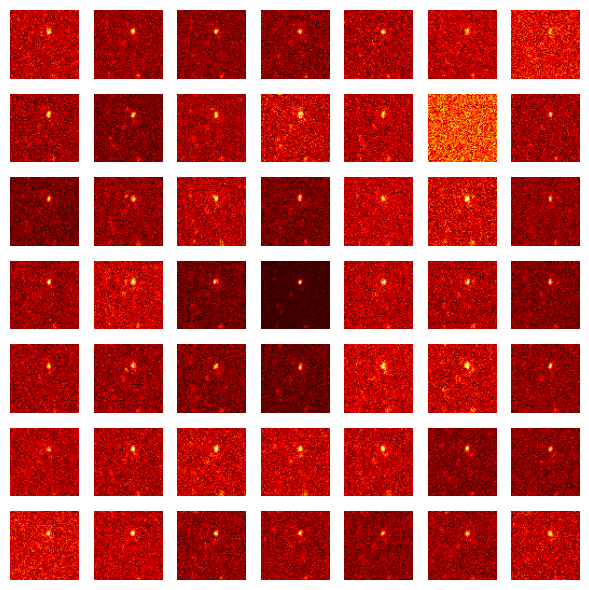

In [14]:
dataPMT = data[0,0,:,:,0,:] # (y,x,ch)

gra.ShowDataset(dataPMT)
plt.show()